In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")
root.gStyle.SetPalette(1)
#root.gStyle.SetPaintTextFormat("1.1f");
root.gStyle.SetPaintTextFormat("4.2f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and capacitance in [F] #
# this script is meant to analyze the Vgl spread on a single 16x16 device
###################################/

wafer = 12 # sensor wafer
sensor_row = 4 # row on wafer
sensor_col = 2 # column on wafer
n_row=16 # number of rows/columns of the 16x16
n_col=16
start_gl_calculation = 5 #VGL calculated only if the number of bias points is larger than this value
save = False
verbose = True
write_json = True #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2026, 2, 25, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

file_qa = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIES_ETL-site_example_files/16x16_Vgl_uniformity/LC2_W"+str(wafer)+"_"+str(sensor_col)+"-"+str(sensor_row)+"_16x16_GL-uniformity_ETL-site.root")

tree_qa = file_qa.Get("Tree")

#LC2
low_GL_bias = 5.  # low limit of fit (Vgl) (V)
high_GL_bias = 46.  # upper limit of fit (Vbulk) (V)
low_bulk_bias = 48.  # low limit of fit (Vgl) (V)
high_bulk_bias = 50.  # upper limit of fit (Vbulk) (V)
low_trail_bias = 55.  # upper limit of fit (plateau after full depletion) (V)
Vbulk_upper_limit = 10. # as defined in Tender, if Vbulk above this value you will get an error message to check the measurement
k_high = 50.
k_low = 10.

tests_json = []

vcount_vgl_qa = [[0 for i in range(n_row)] for j in range(n_col)] 
vcount_bump_qa = [[0 for i in range(n_row)] for j in range(n_col)] 
vvgl_qa = [[0 for i in range(n_row)] for j in range(n_col)] 
vbulk_qa = [[0 for i in range(n_row)] for j in range(n_col)] 
vc_raw = [[[] for i in range(n_row)] for j in range(n_col)] 
v_raw = [[[] for i in range(n_row)] for j in range(n_col)] 

hVgl_qa = TH2F( "Vgl_qa_W"+str(wafer), "VGL ETL site W"+str(wafer)+" sensor "+str(sensor_col)+"-"+str(sensor_row), n_col,0,n_col,n_row,0,n_row )
hVbulk_qa = TH2F( "Vbulk_qa_W"+str(wafer), "Vbulk ETL site W"+str(wafer)+" sensor "+str(sensor_col)+"-"+str(sensor_row), n_col,0,n_col,n_row,0,n_row )

vgl_list = []
vbulk_list = []


dumb_counter = 0. # Total number of sensors/measurements in the root file
non_empty_counter = 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter = 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
good_fit_counter = 0. #Fraction of sensors whose category can be properly defined
cv_quality = bool()

sensor = "Prototype LGAD"
sensor_geom = "16x16"
vendor = "FBK"
production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "Torino" # where the test was performed

if(write_json):
    json_filename="ETL_site_Vgl_uniformity_W"+str(wafer)+"_"+str(sensor_col)+"-"+str(sensor_row)
    
save_path = '/Users/icosivi/Desktop/'
#wb = pd.read_excel('/Users/icosivi/Desktop/LFoundry/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')
wb = pd.read_excel('/Users/icosivi/Desktop/LFoundry/plot_UFSDLF_LC2/UFSDLF2_16x16_ETLdb.xlsx')

In [3]:
for event in tree_qa:
    dumb_counter+=1
    if(int(event.CPAD.size())>=start_gl_calculation and int(event.V.size())>=start_gl_calculation ):
      non_empty_counter+=1

      if( event.CPAD.at(event.CPAD.size()-1)<0 ): 
        Cpad = [float(-i) for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.pad_column][event.pad_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Cpad = [i for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.pad_column][event.pad_row].append(float(-i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.CPAD.size()-1):
           v_raw[event.pad_column][event.pad_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.CPAD.size()-1): 
           v_raw[event.pad_column][event.pad_row].append(float(-i))
           

      non_zero_capacitance = sum(Cpad) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_capacitance!=0):
        non_zero_counter+=1
    
        cv_quality = True
        VGL_CV = -1000.
        Vbulk_CV = -1000.
      
        V_GL_vector = []
        C_GL_vector = []
        V_GL_vector_error = []
        C_GL_vector_error = []
        V_bulk_vector = []
        C_bulk_vector = []
        V_bulk_vector_error = []
        C_bulk_vector_error = []
        V_trail_vector = []
        C_trail_vector = []
        V_trail_vector_error = []
        C_trail_vector_error = []
        
        ####### VGL calculation #####
        for i in range(len(Cpad)):

          if Vbias[i]>=low_GL_bias and Vbias[i]<=high_GL_bias:
  
            V_GL_vector.append(float(Vbias[i]))
            C_GL_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_GL_vector_error.append(0.06)
            C_GL_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
  
  
          if Vbias[i]>=low_bulk_bias and Vbias[i]<=high_bulk_bias:
  
            V_bulk_vector.append(float(Vbias[i]))
            C_bulk_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_bulk_vector_error.append(0.06)
            C_bulk_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
          
          #if Vbias[i]>high_bulk_bias and Vbias[i]<Vbias[len(Vbias)-1]:
          if Vbias[i]>low_trail_bias and Vbias[i]<Vbias[len(Vbias)-1]:
  
            V_trail_vector.append(float(Vbias[i]))
            C_trail_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_trail_vector_error.append(0.06)
            C_trail_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
        
        V_GL_vector = np.array(V_GL_vector)
        C_GL_vector = np.array(C_GL_vector)
        V_bulk_vector = np.array(V_bulk_vector)
        C_bulk_vector = np.array(C_bulk_vector)
        V_trail_vector = np.array(V_trail_vector)
        C_trail_vector = np.array(C_trail_vector)
        Vbias = np.array(Vbias)
        Cpad = np.array(Cpad)
        g_GL = root.TGraph(len(V_GL_vector),V_GL_vector,C_GL_vector)
        g_bulk = root.TGraph(len(V_bulk_vector),V_bulk_vector,C_bulk_vector)
        g_trail = root.TGraph(len(V_trail_vector),V_trail_vector,C_trail_vector)
        g_total = root.TGraph(len(Vbias),Vbias,Cpad)

        g_GL.Fit("pol1","Q")
        f_gl = g_GL.GetFunction("pol1")
        chi_gl = f_gl.GetChisquare()/f_gl.GetNDF()
        
        g_bulk.Fit("pol1","Q")
        f_bulk = g_bulk.GetFunction("pol1")
        chi_bulk = f_bulk.GetChisquare()/f_bulk.GetNDF()
        
        g_trail.Fit("pol1","Q")
        f_trail = g_trail.GetFunction("pol1")
        chi_trail = f_trail.GetChisquare()/f_trail.GetNDF()
        
        #print("Chi2: "+str(chi_gl)+" "+str(chi_bulk)+" "+str(chi_trail))
        
        g_GL.SetMarkerStyle(20)
        g_bulk.SetMarkerStyle(20)
        g_trail.SetMarkerStyle(20)
        g_total.SetMarkerStyle(20)
        g_GL.SetLineWidth(0)
        g_bulk.SetLineWidth(0)
        g_trail.SetLineWidth(0)
        g_total.SetLineWidth(0)
        
        mg = root.TMultiGraph()
        mg.Add(g_GL,"lp")
        mg.Add(g_bulk,"cp")
        mg.Add(g_trail,"cp")
        mg.Add(g_total,"cp")
        #mg.Draw("apl")
        #mg.SaveAs("/Users/icosivi/Desktop/pippo/"+str(event.event)+".root")
        
        f_GL = g_GL.GetFunction("pol1")
        f_bulk = g_bulk.GetFunction("pol1")
        f_trail = g_trail.GetFunction("pol1")

        m_GL = f_GL.GetParameter(1)
        q_GL = f_GL.GetParameter(0)
        m_bulk = f_bulk.GetParameter(1)
        q_bulk = f_bulk.GetParameter(0)
        m_trail = f_trail.GetParameter(1)
        q_trail = f_trail.GetParameter(0)

        VGL_CV = (q_bulk-q_GL)/(m_GL-m_bulk)
        Vbulk_CV = (q_trail-q_bulk)/(m_bulk-m_trail) - VGL_CV
        print(str(VGL_CV)+" "+str(Vbulk_CV))
        
        if( VGL_CV>low_GL_bias and VGL_CV<high_bulk_bias and Vbulk_CV>0. and Vbulk_CV<Vbulk_upper_limit ):
          good_fit_counter += 1
          vvgl_qa[event.pad_column][event.pad_row] += VGL_CV
          vbulk_qa[event.pad_column][event.pad_row] += Vbulk_CV
          vcount_bump_qa[event.pad_column][event.pad_row] += 1
          vgl_list.append( VGL_CV )
          vbulk_list.append( Vbulk_CV )
        else: 
          vcount_bump_qa[event.pad_column][event.pad_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(wafer)+" row "+str(sensor_row)+" column "+str(sensor_col)+" pad: (row) "+str(event.pad_row)+" (column) "+str(event.pad_column)+": VGL or Vbulk could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.pad_column][event.pad_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(wafer)+" row "+str(sensor_row)+" column "+str(sensor_col)+" pad: (row) "+str(event.pad_row)+" (column) "+str(event.pad_column)+" has Voltage and/or Capacitance always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.pad_column][event.pad_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(wafer)+" row "+str(sensor_row)+" column "+str(sensor_col)+" pad: (row) "+str(event.pad_row)+" (column) "+str(event.pad_column)+": Voltage and/or Capacitance vectors have less than "+str(start_gl_calculation)+" elements. PLEASE CHECK.")

48.60919995643902 2.4333007541365745
48.040917000554934 1.6737439374788536
48.416650178747076 1.3889213662569304
48.499118494853434 1.4821541315635969
47.90130191511732 1.757330629001018
48.45178918353877 1.5519797316091513
48.54537030841932 3.4895104578497538
48.122117750801664 1.6113485965766685
48.35831778017068 1.65027937913365
48.517784723255446 1.5881760344939337
48.38744014627956 1.7741761051440292
48.33352792160721 1.3097816660680195
48.380815522906836 1.7662404714943065
48.47317256229923 2.7989191597651626
48.35557066216531 1.6664785648790854
48.082328636320455 1.4815781809947453
48.504666936814154 1.501664847220745
48.59402720055367 1.820224909784116
48.09338349092799 1.4911977644618233
48.049602592302655 1.6609954359642956
48.699647431451666 8.669535925148736
48.292447908413315 1.4899005923079756
48.193324285497035 1.5838152413903117
48.365415156178074 1.4431824269334115
48.20079438331591 1.5201721416347667
48.61413005931025 1.868756845524473
48.34477039598316 1.480203235307

In [4]:
import statistics
uniformity = float((statistics.stdev(vgl_list)/statistics.mean(vgl_list))*100)

print("VGL:")
print(statistics.mean(vgl_list))
print(statistics.stdev(vgl_list))
print(" ")
print("uniformity:")
print(str(uniformity))

VGL:
48.37776108281173
0.19118637008024236
 
uniformity:
0.39519474610033056


In [5]:
v_serialn = str(wb[(wb['Wafer'] == wafer) & (wb['Row'] == sensor_row) & (wb['Column'] == sensor_col)]['SerialNumber'].iloc[0])

In [6]:
pippo = {'component': v_serialn,
         'name': 'Sensor Gain Layer Uniformity',
         'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
         'location': location,
         'user_created': user,
         'version': 'v0',
         'gain_layer_uniformity': uniformity
         #'data':{
         # 'side': side,
         # 'geometry': sensor_geom,
         # 'vgl': vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k],
         # 'vbulk_V': vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k],
         # 'gain_category': None,
         # 'capacitance': vc_raw[i][j][k],
         # 'voltage': v_raw[i][j][k]
         #}
        }

tests_json.append(pippo)

if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

In [7]:
for j in range(n_col):
        for k in range(n_row):
             if(vcount_bump_qa[j][k] > 0):
               hVgl_qa.Fill( j, k, vvgl_qa[j][k]/vcount_bump_qa[j][k] )
               hVbulk_qa.Fill( j, k, vbulk_qa[j][k]/vcount_bump_qa[j][k] )

if(verbose):
  print("Fraction of non-empty CVs: "+str(non_empty_counter/dumb_counter))
  print("Fraction of CVs with non-zero values: "+str(non_zero_counter/dumb_counter))
  print("Fraction of succesfull fits: "+str(good_fit_counter/non_zero_counter))

Fraction of non-empty CVs: 1.0
Fraction of CVs with non-zero values: 1.0
Fraction of succesfull fits: 1.0


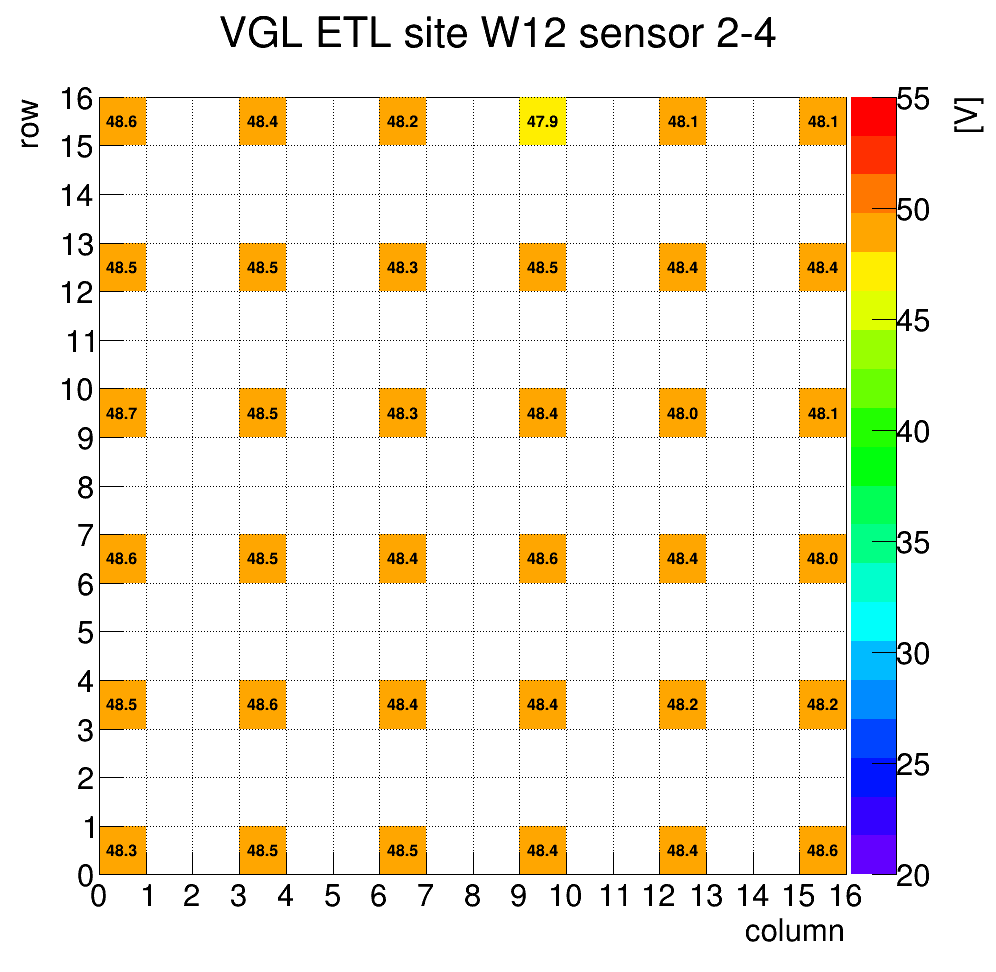

In [8]:
cC = root.TCanvas("c_C_W"+str(wafer), "c VGL_W"+str(wafer), 1000,1000)

#hVgl_qa[i].GetZaxis().SetRangeUser( low_GL_bias[i], high_bulk_bias[i] )
hVgl_qa.GetZaxis().SetRangeUser( 20., 55. ) # Tender acceptance ranges
hVgl_qa.GetZaxis().SetTitle("[V]")
hVgl_qa.GetXaxis().SetTitle("column") 
hVgl_qa.GetYaxis().SetTitle("row")
hVgl_qa.SetMarkerSize(3.)
root.gStyle.SetPaintTextFormat("1.1f")
#cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
cC.SetRightMargin(0.15)
cC.cd()
hVgl_qa.SetMarkerSize(0.9)
hVgl_qa.Draw("textcolz")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cC.Update()
hVgl_qa.GetXaxis().SetNdivisions(n_col)
hVgl_qa.GetYaxis().SetNdivisions(n_row)
  
if(save): 
      cC.SaveAs(save_path+"VGL_W"+str(wafer)+"_sensor_column_"+str(sensor_col)+"_row_"+str(sensor_row)+".png")    

In [ ]:
cD = root.TCanvas("c_D_W"+str(wafer), "c Vbulk_W"+str(wafer), 1000,1000)

#hVgl_qa[i].GetZaxis().SetRangeUser( low_GL_bias[i], high_bulk_bias[i] )
hVbulk_qa.GetZaxis().SetRangeUser( 0., 10. ) # Tender acceptance ranges
hVbulk_qa.GetZaxis().SetTitle("[V]")
hVbulk_qa.GetXaxis().SetTitle("column") 
hVbulk_qa.GetYaxis().SetTitle("row")
hVbulk_qa.SetMarkerSize(3.)
root.gStyle.SetPaintTextFormat("1.1f")
#cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
cD.SetRightMargin(0.15)
cD.cd()
hVbulk_qa.SetMarkerSize(0.9)
hVbulk_qa.Draw("textcolz")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cD.Update()
hVbulk_qa.GetXaxis().SetNdivisions(n_col)
hVbulk_qa.GetYaxis().SetNdivisions(n_row)
  
if(save): 
      cC.SaveAs(save_path+"Vbulk_W"+str(wafer)+"_sensor_column_"+str(sensor_col)+"_row_"+str(sensor_row)+".png")